In [24]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,confusion_matrix, classification_report 
import matplotlib.pyplot as plt 

In [25]:
df = pd.read_csv('your_file.csv')
print(df.head())

   Experience  Education  Age  Salary
0           1         12   22   25000
1           2         12   24   30000
2           3         14   26   38000
3           4         14   28   45000
4           5         15   30   52000


In [26]:
salary=df['Salary']

In [27]:
conditions = [ 
                salary < 45000, 
                (salary >= 45000) & (salary < 75000), 
                salary >= 75000 
            ] 

In [28]:
choices = [0, 1, 2] 
df['SalaryClass'] = np.select(conditions, choices)

In [29]:
X = df[['Experience', 'Education', 'Age']] 
y = df['SalaryClass'] 

In [30]:
X_train, X_test, y_train, y_test = train_test_split( 
X, y, test_size=0.3, random_state=42, stratify=y 
) 

In [31]:
scaler = StandardScaler() 
X_train_scaled = scaler.fit_transform(X_train) 
X_test_scaled = scaler.transform(X_test)

In [32]:
knn = KNeighborsClassifier(n_neighbors=3) 
knn.fit(X_train_scaled, y_train)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [33]:
y_pred = knn.predict(X_test_scaled)

In [34]:
acc = accuracy_score(y_test, y_pred)

In [35]:
prec_macro = precision_score(y_test, y_pred, average='macro', zero_division=0) 
rec_macro  = recall_score(y_test, y_pred, average='macro', zero_division=0) 
f1_macro   = f1_score(y_test, y_pred, average='macro', zero_division=0) 
prec_weighted = precision_score(y_test, y_pred, average='weighted', zero_division=0) 
rec_weighted  = recall_score(y_test, y_pred, average='weighted', zero_division=0) 
f1_weighted   = f1_score(y_test, y_pred, average='weighted', zero_division=0)

In [36]:
print("Accuracy:", acc) 

print("\nMacro Average:") 
print("Precision (Macro):", prec_macro) 
print("Recall (Macro):   ", rec_macro) 
print("F1-score (Macro): ", f1_macro) 

print("\nWeighted Average:") 
print("Precision (Weighted):", prec_weighted) 
print("Recall (Weighted):   ", rec_weighted) 
print("F1-score (Weighted): ", f1_weighted) 

Accuracy: 1.0

Macro Average:
Precision (Macro): 1.0
Recall (Macro):    1.0
F1-score (Macro):  1.0

Weighted Average:
Precision (Weighted): 1.0
Recall (Weighted):    1.0
F1-score (Weighted):  1.0


In [37]:
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred)) 
print("\nClassification Report:\n", 
classification_report(y_test, y_pred, 
target_names=['Low', 'Medium', 'High'], 
zero_division=0))


Confusion Matrix:
 [[1 0 0]
 [0 1 0]
 [0 0 1]]

Classification Report:
               precision    recall  f1-score   support

         Low       1.00      1.00      1.00         1
      Medium       1.00      1.00      1.00         1
        High       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



In [38]:
input_data = [[6, 16, 30]] 
input_scaled = scaler.transform(input_data) 

E:\anaconda3\envs\ml_lab\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [39]:
predicted_class = knn.predict(input_scaled)[0] 
labels = ['Low', 'Medium', 'High'] 
print("\nPredicted Class:", labels[predicted_class])


Predicted Class: Medium


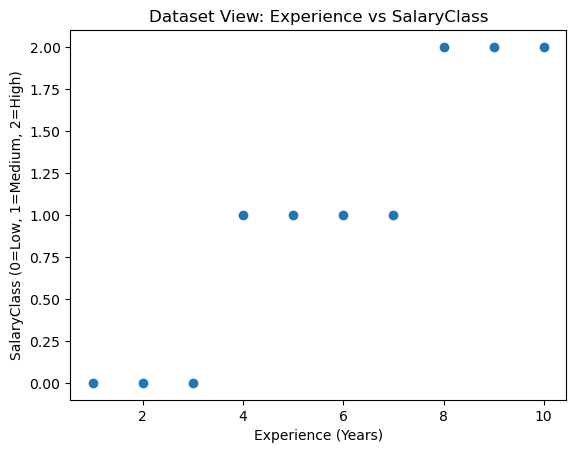

In [40]:
plt.scatter(df['Experience'], df['SalaryClass']) 
plt.xlabel("Experience (Years)") 
plt.ylabel("SalaryClass (0=Low, 1=Medium, 2=High)") 
plt.title("Dataset View: Experience vs SalaryClass") 
plt.show()